In [13]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df = pd.read_csv('resultados copy.csv', sep=',')
df=df[1:]

grafos = df['Grafo'].unique().tolist()
algoritmos = df['Algoritmo'].unique().tolist()
vetor_df = []
for g in grafos:
    for a in algoritmos:
        dfTemp = df.loc[df['Grafo'] == g].loc[df['Algoritmo'] == a]
        vetor_df.append([g, a, dfTemp])

display(len(vetor_df))





12

## Comparativo todos cenarios   

In [14]:
dfGeral = pd.DataFrame(columns=['Grafo', 'Algoritmo', 'Fit Inicial Médio', 'Fit Melhor Médio', 'Tempo Execução Médio (s)', 'Ganho Relativo Médio (%)'])



for df in vetor_df:
    tempo_execucao = []
    ganho_relativo = []
    grafo = df[0]
    algoritmo = df[1][3:]
    texto = (grafo + algoritmo).replace(" ", "_").replace("-", "_")
    dataframe = df[2]
    fit_inicial_medio = np.mean(dataframe['Fit Inicial'].astype(float))
    fit_melhor_medio = np.mean(dataframe['Fit Final'].astype(float))
    tempo = np.mean(dataframe['Tempo Execução (s)'].astype(float))
    tempo_execucao.append(tempo)
    tempo_execucao_medio = tempo
    ganho = np.mean(dataframe['Ganho Relativo (%)'].astype(float))
    ganho_relativo.append(ganho)
    ganho_relativo_medio = ganho

    dfGeral = pd.concat([dfGeral, pd.DataFrame([[grafo, algoritmo, fit_inicial_medio, fit_melhor_medio, tempo_execucao_medio, ganho_relativo_medio]], columns=dfGeral.columns)], ignore_index=True)


display(dfGeral)


/tmp/ipykernel_157959/2976159062.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfGeral = pd.concat([dfGeral, pd.DataFrame([[grafo, algoritmo, fit_inicial_medio, fit_melhor_medio, tempo_execucao_medio, ganho_relativo_medio]], columns=dfGeral.columns)], ignore_index=True)


,Grafo,Algoritmo,Fit Inicial Médio,Fit Melhor Médio,Tempo Execução Médio (s),Ganho Relativo Médio (%)
0,berlin52,1DeleteCross,25791.739307,9614.496690,3.462581,62.701355
1,berlin52,1DC-Solucao-Cluster2x2,26073.291800,11553.865528,2.827791,55.649234
2,berlin52,1DC-AG-Cluster2x2,26143.103457,11662.502209,2.933044,55.373086
3,berlin52,Original,25397.805328,13811.171852,0.883190,45.602492
4,ch150,1DeleteCross,48771.190571,19465.285119,12.469533,60.052589
5,ch150,1DC-Solucao-Cluster2x2,49091.835632,9915.153949,13.562460,79.796072
6,ch150,1DC-AG-Cluster2x2,49000.031186,9720.364930,13.394947,80.158836
7,ch150,Original,48964.951519,28570.697674,4.259155,41.619730
8,rd400,1DeleteCross,201068.759907,81547.359766,55.114813,59.438906
9,rd400,1DC-Solucao-Cluster2x2,200381.146123,37738.291761,29.080731,81.165361


# Comparativo por Cluster

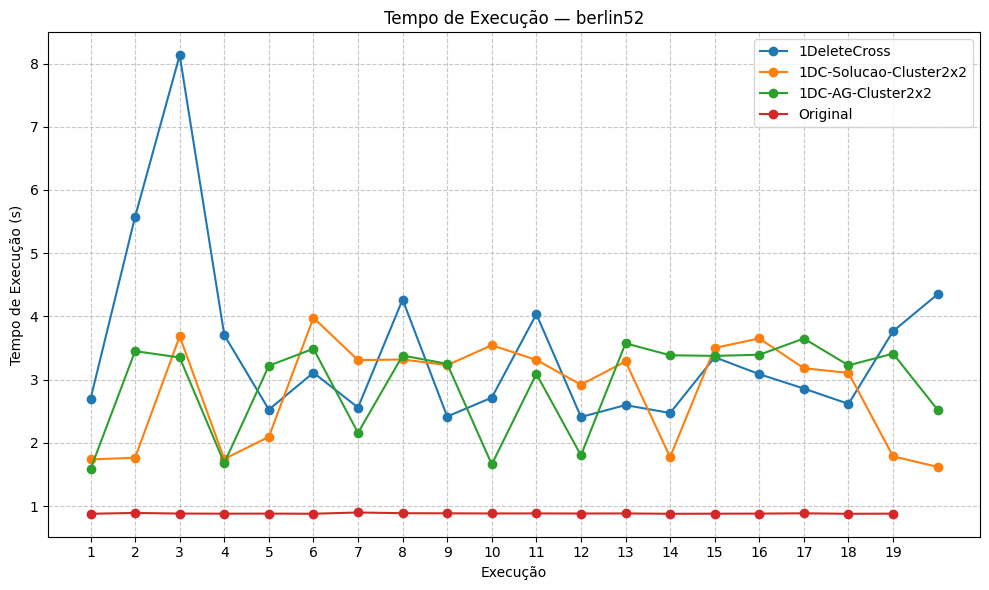

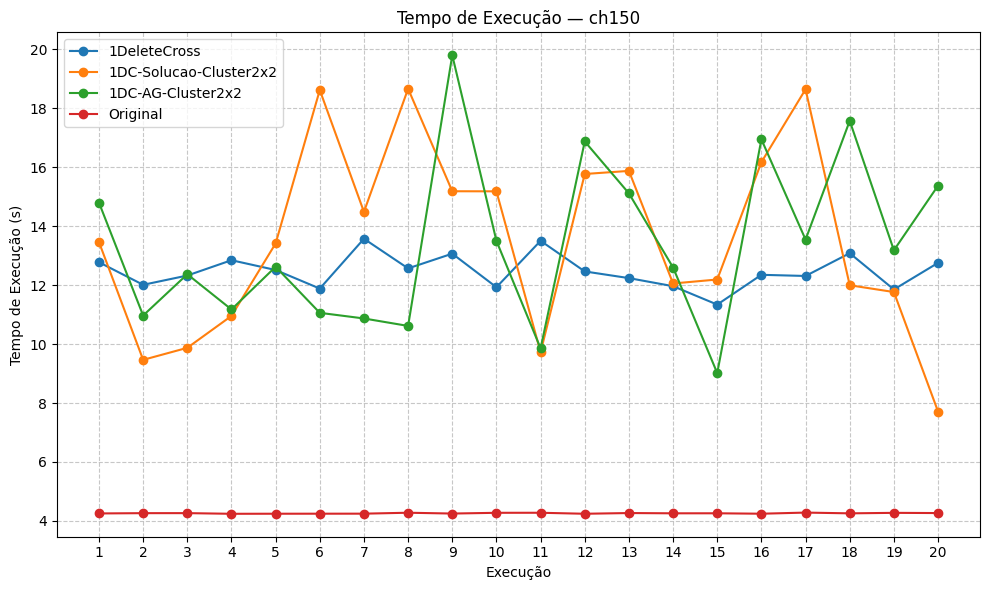

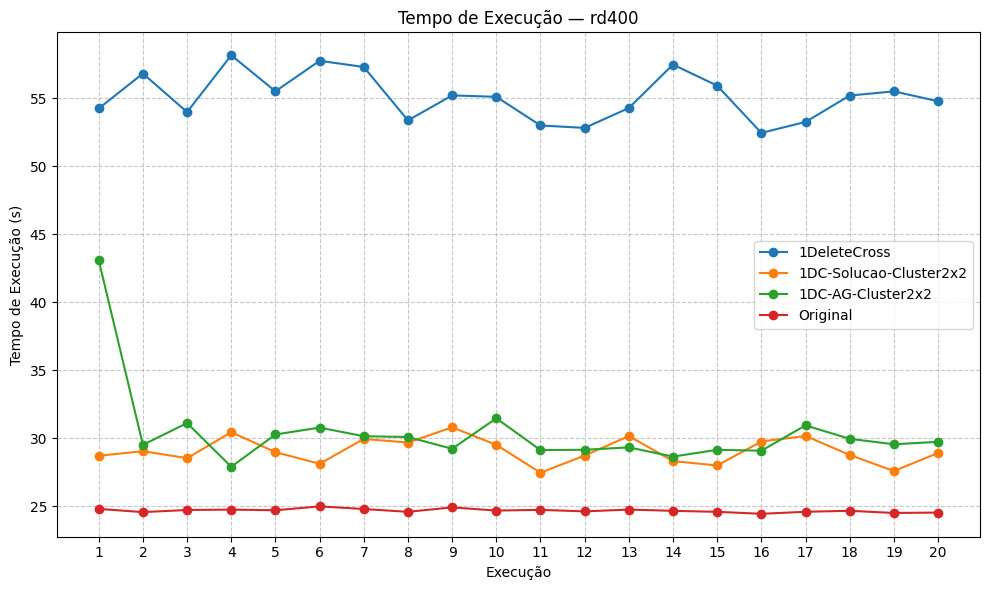

In [15]:
import os
import matplotlib.pyplot as plt

title = True

os.makedirs("graficos", exist_ok=True)
plt.style.use('fast')

for g in grafos:
    vetor = [item for item in vetor_df if item[0] == g]

    plt.figure(figsize=(10, 6))

    for item in vetor:
        algoritmo = item[1][3:].replace(" ", "_")
        dftemp = item[2]
        valores_tempo = dftemp['Tempo Execução (s)'].astype(float).tolist()
        n = len(valores_tempo)
        x = list(range(1, n + 1))
        plt.plot(x, valores_tempo, marker="o", label=algoritmo)

    plt.xticks(ticks=list(range(1, n + 1)), labels=list(range(1, n + 1)))
    plt.xlabel("Execução")
    plt.ylabel("Tempo de Execução (s)")
    if title:
        plt.title(f"Tempo de Execução — {g}")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.7)
    nome_arquivo = f"graficos/tempos_execucao_{g}.png"
    plt.savefig(nome_arquivo, dpi=150)
    plt.show()


In [16]:
nome_geral = "resultados_geral.csv"
nome_tabela = "tabelas/" + nome_geral

dfGeral.to_csv(nome_tabela, index=False, float_format='%.2f')
dfGeral.to_latex(nome_tabela.replace(".csv", ".tex"), index=False, float_format='%.2f')